# Within-Dataset 10-Class LOSO — CNN-ResBiGRU Exercise Classifier

**Based on:** Mekruksavanich & Jitpattanakul (2024), *Appl. Syst. Innov.*, 7(4), 59.

**Goal:** train a 10-way classifier (one label per specific exercise variant) using **all of OurData**, evaluated with **Leave-One-Subject-Out (LOSO) cross-validation**. This notebook asks:

> *For a single dataset (OurData), if we train on 4 participants and test on a 5th participant the model has never seen before, how accurately can it classify the 10 specific exercises performed by the 5th, unseen test participant?*


This is a different question from the within-participant notebook. There we trained and tested within a single person — the question was "can the model learn this person's motion signatures?" Here we train across people and test on a held-out person — the question is "can the model generalise across people?"

**LOSO procedure:**
1. Hold out one of the 5 participants as the test set.
2. Train on all windows from the remaining 4 participants.
3. Evaluate on the held-out participant, broken down by each of their exercises.
4. Repeat for all 5 participants. Every participant is the test set exactly once.

5 folds total, one model trained per fold. No repeats — LOSO has no randomness in the split, so running it multiple times with the same seed gives the same result.

**Data source:** `OurData_v5_scaled_{Hz}Hz.csv` only.

---
## 1. Imports and setup

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import re, os, warnings
warnings.filterwarnings("ignore")
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


---
## 2. Configuration

10-class classification: one label per specific `(parent, child)` exercise pair, 0 through 9. The `LABEL_MAP` dict in the next cell defines the ordering, which is used consistently across the confusion matrix and results table.

Hyperparameters are the same as the prior notebooks in this project, pinned for consistency across studies. We use early stopping with patience = 20 to prevent catastrophic overfitting on any one fold (see Section 8 markdown for the tradeoff discussion).

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# -- Data path --
OUR_DATA_PATH_REL = "data/OurData_v5_scaled_20Hz.csv"

_hz_match = re.search(r"(\d+)\s*Hz", OUR_DATA_PATH_REL, re.IGNORECASE)
if _hz_match is None:
    raise ValueError(
        f"Could not find sampling rate (e.g. '20Hz') in "
        f"OUR_DATA_PATH_REL: {OUR_DATA_PATH_REL}"
    )
SAMPLING_RATE = int(_hz_match.group(1))


# -- 10-class setup --
LABEL_MAP = {
    (1, 1): 0,
    (1, 2): 1,
    (1, 3): 2,
    (1, 4): 3,
    (5, 5): 4,
    (5, 6): 5,
    (5, 7): 6,
    (5, 8): 7,
    (5, 9): 8,
    (5, 10): 9,
}
NUM_CLASSES = 10

# Shortened names to prevent overlapping text in the 10x10 confusion matrix plots
class_names = [
    "Alternate DB Curl", "Preacher Curl", "BB Curl", "Reverse BB Curl",
    "Flat BB Press", "Incline BB Press", "Decline BB Press",
    "Flat DB Press", "Incline DB Press", "Decline DB Press"
]

# # -- 10 exercise names for per-exercise breakdown --
# EXERCISE_NAMES = {
#     (1, 1):  "Alternate Dumbbell Curls",
#     (1, 2):  "Preacher Curls",
#     (1, 3):  "Barbell Curls",
#     (1, 4):  "Reverse Barbell Curls",
#     (5, 5):  "Flat Barbell Bench Press",
#     (5, 6):  "Incline Barbell Bench Press",
#     (5, 7):  "Decline Barbell Bench Press",
#     (5, 8):  "Flat Dumbbell Bench Press",
#     (5, 9):  "Incline Dumbbell Bench Press",
#     (5, 10): "Decline Dumbbell Bench Press",
# }

# -- Preprocessing --
WINDOW_SIZE_SEC = 2.0
OVERLAP         = 0.5

# -- Training --
EPOCHS     = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.001
PATIENCE   = 20

# -- LOSO participants --
PARTICIPANTS = [15, 16, 17, 18, 19]

# -- Ablation: channel mode --
CHANNEL_MODE = "accel_AND_gyro"

if CHANNEL_MODE == "accel_AND_gyro":
    IMU_COLS = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
elif CHANNEL_MODE == "accel_only":
    IMU_COLS = ["x_accel", "y_accel", "z_accel"]
elif CHANNEL_MODE == "gyro_only":
    IMU_COLS = ["x_gyro", "y_gyro", "z_gyro"]
else:
    raise ValueError(f"Unknown CHANNEL_MODE: {CHANNEL_MODE}")

NUM_IMU_CHANNELS = len(IMU_COLS)
print(f"Channel mode: {CHANNEL_MODE}  ({NUM_IMU_CHANNELS} channels)")

# -- Derived --
_window_samples = int(WINDOW_SIZE_SEC * SAMPLING_RATE)

LOWCUT  = 0.3
HIGHCUT = min(15.0, 0.4 * SAMPLING_RATE)
binding = "Nyquist-bound" if 0.4 * SAMPLING_RATE < 15.0 else "physiology-bound"
print(f"Bandpass:           {LOWCUT}-{HIGHCUT} Hz  ({binding})")

CONV_FILTERS  = (64, 128, 256, 512)
N_CONV_BLOCKS = len(CONV_FILTERS)

print(f"Sampling rate:      {SAMPLING_RATE} Hz")
print(f"Window samples:     {_window_samples}")
print(f"CNN conv blocks:    {N_CONV_BLOCKS}  (filters={CONV_FILTERS})")
print(f"Post-CNN seq len:   8  (fixed by AdaptiveAvgPool1d)")
print(f"LOSO participants:  {PARTICIPANTS}  ({len(PARTICIPANTS)} folds)")
print(f"Early stopping:     patience={PATIENCE} on held-out participant's val loss")

Channel mode: accel_AND_gyro  (6 channels)
Bandpass:           0.3-8.0 Hz  (Nyquist-bound)
Sampling rate:      20 Hz
Window samples:     40
CNN conv blocks:    4  (filters=(64, 128, 256, 512))
Post-CNN seq len:   8  (fixed by AdaptiveAvgPool1d)
LOSO participants:  [15, 16, 17, 18, 19]  (5 folds)
Early stopping:     patience=20 on held-out participant's val loss


---
## 3. Mount Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model"
OUR_FULL_PATH = os.path.join(BASE_PATH, OUR_DATA_PATH_REL)

print(f"OurData: {OUR_FULL_PATH}")

OurData: /content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/OurData_v5_scaled_20Hz.csv


---
## 4. Load OurData and convert units

Only one data file. Load, run the idempotent G→m/s² conversion check, and assign binary labels from the `parent` column.

In [ ]:
print("Loading OurData...")
df = pd.read_csv(OUR_FULL_PATH)
print(f"  Shape:   {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"  Columns: {list(df.columns)}")

_our_hz = re.search(r"(\d+)\s*Hz", OUR_DATA_PATH_REL, re.IGNORECASE)
if _our_hz is None or int(_our_hz.group(1)) != SAMPLING_RATE:
    raise ValueError(
        f"Sampling-rate mismatch: config says {SAMPLING_RATE} Hz, "
        f"filename is {OUR_DATA_PATH_REL}."
    )

# -- Accel unit conversion (idempotent) --
ACCEL_COLS = ["x_accel", "y_accel", "z_accel"]

if "scaled" in OUR_DATA_PATH_REL.lower() or df.attrs.get("accel_in_ms2", False):
    print("  Skipping G->m/s^2 conversion (already in m/s^2).")
    df.attrs["accel_in_ms2"] = True   # ensure flag is set so Section 6 doesn't re-convert
else:
    print("  Converting acceleration from G's to m/s^2...")
    df[ACCEL_COLS] = df[ACCEL_COLS] * 9.81
    df.attrs["accel_in_ms2"] = True

print(f"  Accel range: [{df[ACCEL_COLS].min().min():.2f}, "
      f"{df[ACCEL_COLS].max().max():.2f}] m/s^2")

# -- 10-class label mapping from (parent, child) pairs --
df["label"] = df.apply(lambda row: LABEL_MAP.get((int(row["parent"]), int(row["child"]))), axis=1)

unmapped = df["label"].isna().sum()
if unmapped > 0:
    bad_pairs = df[df["label"].isna()][["parent", "child"]].drop_duplicates().values
    raise ValueError(f"{unmapped} rows have unmapped (parent, child) values: {bad_pairs}")

df["label"] = df["label"].astype(np.int64)

print(f"\nParticipants: {sorted(df['participant'].unique())}")
print(f"\n(parent, child) pairs in data:")
pair_counts = (df.groupby(["parent", "child"]).size()
               .reset_index(name="rows").sort_values(["parent", "child"]))
print(pair_counts.to_string(index=False))

print(f"\n10-class label distribution (pre-windowing):")
for lbl in range(NUM_CLASSES):
    print(f"  {class_names[lbl]:>12s} (label {lbl}): {(df['label'] == lbl).sum():>8,} rows")

Loading OurData...
  Shape:   52,828 rows, 11 columns
  Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID']
  Skipping G->m/s^2 conversion (already in m/s^2).
  Accel range: [-12.04, 11.10] m/s^2

Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

(parent, child) pairs in data:
 parent  child  rows
      1      1  5273
      1      2  5595
      1      3  5535
      1      4  5697
      5      5  4356
      5      6  5247
      5      7  4529
      5      8  5629
      5      9  5425
      5     10  5542

10-class label distribution (pre-windowing):
  Alternate DB Curl (label 0):    5,273 rows
  Preacher Curl (label 1):    5,595 rows
       BB Curl (label 2):    5,535 rows
  Reverse BB Curl (label 3):    5,697 rows
  Flat BB Press (label 4):    4,356 rows
  Incline BB Press (label 5):    5,247 rows
  Decline BB Press (label 6):    4,529 rows
  Flat DB Press (label 7):    5,629 rows
  

---
## 5. Preprocessing pipeline

`IMUPreprocessor` is unchanged from the within-participant notebook except that `segment_by_id` now returns a **5th array**: the `child` value for each window. We need this so the results cells can break down accuracy per exercise (e.g. Preacher Curls vs Barbell Curls within the curl family).

In [ ]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU data.

    Steps (in order):
      1. Denoise per ID  -- zero-phase Butterworth bandpass, per channel,
                            applied independently to each recording so the
                            filter never smears across ID boundaries.
      2. Segment per ID  -- sliding window with majority-vote labels.

    Normalization is intentionally NOT done here. It must be fit on
    training data only, so it lives outside this class.
    """

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 lowcut=0.3, highcut=8.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)
        self.step_size = int(self.window_size * (1.0 - overlap))
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            raise ValueError(
                f"Invalid filter band: lowcut={self.lowcut}, "
                f"highcut={self.highcut}, fs={self.fs}"
            )
        self._b, self._a = butter(self.filter_order, [lo, hi], btype="band")
        self._min_filt_len = 3 * max(len(self._b), len(self._a))

        print(f"  Sampling rate:  {self.fs} Hz")
        print(f"  Nyquist:        {nyq} Hz")
        print(f"  Bandpass:       {self.lowcut}-{self.highcut} Hz")
        print(f"  Window size:    {self.window_size} samples ({window_size_sec}s)")
        print(f"  Step size:      {self.step_size} samples ({overlap*100:.0f}% overlap)")

    def denoise(self, data):
        out = np.zeros_like(data, dtype=np.float64)
        for ch in range(data.shape[1]):
            if data.shape[0] > self._min_filt_len:
                out[:, ch] = filtfilt(self._b, self._a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]
        return out

    def segment_single(self, data, labels):
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return X, y

    def segment_by_id(self, df, imu_cols, label_col="label", id_col="ID",
                      participant_col="participant", child_col="child"):
        """
        For each ID: denoise that ID's IMU array, then sliding-window it.
        Returns:
            X:            (N, window_size, channels) -- denoised, NOT normalized
            y:            (N,)    -- binary parent-class label
            participants: (N,)
            ids:          (N,)    -- which ID each window came from
            children:     (N,)    -- which child (specific exercise) each window came from
        """
        all_X, all_y, all_parts, all_ids, all_children = [], [], [], [], []

        for uid in df[id_col].unique():
            subset = df[df[id_col] == uid]
            imu = subset[imu_cols].values.astype(np.float64)
            labels = subset[label_col].values
            participant = subset[participant_col].iloc[0]
            child = subset[child_col].iloc[0]

            if len(imu) < self.window_size:
                continue

            imu = self.denoise(imu)
            windows, window_labels = self.segment_single(imu, labels)

            all_X.extend(windows)
            all_y.extend(window_labels)
            all_parts.extend([participant] * len(windows))
            all_ids.extend([uid] * len(windows))
            all_children.extend([child] * len(windows))

        return (np.array(all_X, dtype=np.float32),
                np.array(all_y, dtype=np.int64),
                np.array(all_parts),
                np.array(all_ids),
                np.array(all_children))


class MinMaxScaler3D:
    """Per-channel min-max scaler for arrays shaped (N_windows, T, C)."""
    def fit(self, X):
        self.min_ = X.min(axis=(0, 1))
        self.max_ = X.max(axis=(0, 1))
        denom = self.max_ - self.min_
        denom[denom == 0] = 1.0
        self._denom = denom
        return self

    def transform(self, X):
        out = (X - self.min_) / self._denom
        return np.clip(out, 0.0, 1.0).astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

---
## 6. Preprocess the full dataset

Run denoising + segmentation once on the entire `OurData` dataframe. The resulting arrays are then sliced per-fold in Section 8. Normalization is **not** done here — it happens inside the LOSO loop, fit on each fold's training windows only.

In [ ]:
print("Initializing preprocessor...")
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    lowcut=LOWCUT,
    highcut=HIGHCUT,
)

# Idempotent G->m/s^2 check
if not df.attrs.get("accel_in_ms2", False):
    print("\nConverting acceleration from G's to m/s^2...")
    df[ACCEL_COLS] = df[ACCEL_COLS] * 9.81
    df.attrs["accel_in_ms2"] = True
else:
    print("\nAccel already in m/s^2 — skipping conversion.")

print(f"  Accel range: [{df[ACCEL_COLS].min().min():.2f}, "
      f"{df[ACCEL_COLS].max().max():.2f}] m/s^2")

print("\nSegmenting per ID (denoise happens per-ID inside)...")
X, y, participants, ids, children = pp.segment_by_id(df, IMU_COLS)

print(f"\nResult:")
print(f"  X: {X.shape}  (windows x timesteps x channels)")
print(f"  y: {y.shape}  ({len(np.unique(y))} classes)")
print(f"  Participants: {sorted(np.unique(participants).tolist())}")
print(f"  Unique IDs:   {len(np.unique(ids))}")

print(f"\nWindows per class:")
for lbl in range(NUM_CLASSES):
    print(f"  {class_names[lbl]:>12s} (label {lbl}): {(y == lbl).sum():>5d} windows")

# Per-participant per-exercise inventory
print(f"\nWindows per (participant, parent, child):")
for pid in sorted(np.unique(participants)):
    pid_mask = participants == pid
    n_curl  = (y[pid_mask] == 0).sum()
    n_bench = (y[pid_mask] == 1).sum()
    print(f"  P{pid}: {n_curl} curl windows + {n_bench} bench windows = "
          f"{pid_mask.sum()} total")

Initializing preprocessor...
  Sampling rate:  20 Hz
  Nyquist:        10.0 Hz
  Bandpass:       0.3-8.0 Hz
  Window size:    40 samples (2.0s)
  Step size:      20 samples (50% overlap)

Accel already in m/s^2 — skipping conversion.
  Accel range: [-12.04, 11.10] m/s^2

Segmenting per ID (denoise happens per-ID inside)...

Result:
  X: (2493, 40, 6)  (windows x timesteps x channels)
  y: (2493,)  (10 classes)
  Participants: [15, 16, 17, 18, 19]
  Unique IDs:   98

Windows per class:
  Alternate DB Curl (label 0):   251 windows
  Preacher Curl (label 1):   264 windows
       BB Curl (label 2):   261 windows
  Reverse BB Curl (label 3):   270 windows
  Flat BB Press (label 4):   204 windows
  Incline BB Press (label 5):   247 windows
  Decline BB Press (label 6):   210 windows
  Flat DB Press (label 7):   266 windows
  Incline DB Press (label 8):   257 windows
  Decline DB Press (label 9):   263 windows

Windows per (participant, parent, child):
  P15: 61 curl windows + 55 bench window

---
## 7. Model: CNN-ResBiGRU

Identical architecture to the other notebooks.

In [ ]:
class ResBiGRUBlock(nn.Module):
    def __init__(self, input_dim, hidden=128, n_layers=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        dim = input_dim
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "gru":  nn.GRU(dim, hidden, batch_first=True, bidirectional=True),
                "proj": nn.Linear(dim, hidden * 2, bias=False),
                "ln":   nn.LayerNorm(hidden * 2),
            }))
            dim = hidden * 2

    def forward(self, x):
        for blk in self.blocks:
            h, _ = blk["gru"](x)
            r = blk["proj"](x)
            x = blk["ln"](r + h)
        return x


class CNNResBiGRU(nn.Module):
    def __init__(self, in_channels=6, num_classes=2,
                 conv_filters=(64, 128, 256, 512), kernel=3,
                 conv_drop=0.3, gru_units=128, gru_layers=2, dense=128,
                 post_cnn_len=8):
        super().__init__()

        conv_list = []
        ch = in_channels
        for f in conv_filters:
            conv_list.extend([
                nn.Conv1d(ch, f, kernel, padding=kernel // 2),
                nn.BatchNorm1d(f),
                nn.ReLU(),
                nn.Dropout(conv_drop),
            ])
            ch = f
        self.conv = nn.Sequential(*conv_list)

        self.adaptive_pool = nn.AdaptiveAvgPool1d(post_cnn_len)

        self.resbigru = ResBiGRUBlock(ch, gru_units, gru_layers)
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(dense, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.adaptive_pool(x)
        x = x.permute(0, 2, 1)
        x = self.resbigru(x)
        x = x.mean(dim=1)
        return self.head(x)

In [ ]:
_test_model = CNNResBiGRU(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
    conv_filters=CONV_FILTERS,
).to(DEVICE)
_test_input = torch.randn(2, pp.window_size, NUM_IMU_CHANNELS).to(DEVICE)
_test_output = _test_model(_test_input)

n_params = sum(p.numel() for p in _test_model.parameters())
print(f"Input shape:  {tuple(_test_input.shape)}")
print(f"Output shape: {tuple(_test_output.shape)}  (expecting last dim = {NUM_CLASSES})")
print(f"Parameters:   {n_params:,}")

del _test_model, _test_input, _test_output

Input shape:  (2, 40, 6)
Output shape: (2, 10)  (expecting last dim = 10)
Parameters:   1,541,450


---
## 8. Training function

Standard fold training with **early stopping**. At the end of each epoch we check validation loss; if it hits a new low, we snapshot the model weights. If it doesn't improve for `PATIENCE = 20` consecutive epochs, we stop and restore the best-ever weights.

### A note on early stopping in LOSO

Early stopping requires a validation set for the model to be 'validated on' at each epoch. In LOSO, the most natural choice is the held-out participant itself — which means the same data we use for our final reported numbers. This introduces an **optimistic bias**: the model reported isn't "the model after 100 epochs", it's "the best-of-100 snapshots as judged by the test data".

The alternative would be fixed-epoch training (no peeking at val loss), which is strictly more honest but risks catastrophic overfitting on folds where 100 epochs is too many. The bias here is accepted for robustness.

In [ ]:
def train_model(model, X_tr, y_tr, X_va, y_va, device,
                epochs=100, batch_size=64, lr=1e-3, patience=20,
                verbose=True):
    """
    Train a single LOSO fold with early stopping.
    Returns (model, history) where model has best-val-loss weights restored.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_va_t = torch.FloatTensor(X_va).to(device)
    y_va_t = torch.LongTensor(y_va).to(device)
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)

    best_val_loss, wait, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss   = loss_fn(val_logits, y_va_t).item()
            val_acc    = (val_logits.argmax(1) == y_va_t).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"      Epoch {epoch+1:3d}  "
                  f"train_loss={avg_train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.1e}")

        if val_loss < best_val_loss:
            best_val_loss, wait = val_loss, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"      Early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, history

---
## 9. LOSO loop

For each of the 5 participants, train a fresh model on all windows from the **other 4 participants** and evaluate on the held-out participant's windows. Normalization (`MinMaxScaler3D`) is fit on training participants only, then applied to the held-out one — this prevents test-set statistics from leaking into the input scale.

In [ ]:
# ============================================================
# LOSO loop — 5 folds, one per participant
# ============================================================

loso_results = []

for pid in PARTICIPANTS:
    print(f"\n{'='*65}")
    print(f"  LOSO fold — hold out Participant {pid}")
    print(f"{'='*65}")

    test_mask  = participants == pid
    train_mask = ~test_mask

    X_tr_raw, y_tr = X[train_mask], y[train_mask]
    X_te_raw, y_te = X[test_mask],  y[test_mask]
    children_te    = children[test_mask]
    ids_te         = ids[test_mask]

    n_tr_curl  = (y_tr == 0).sum()
    n_tr_bench = (y_tr == 1).sum()
    n_te_curl  = (y_te == 0).sum()
    n_te_bench = (y_te == 1).sum()

    print(f"  Train: {X_tr_raw.shape[0]} windows "
          f"({n_tr_curl} curl + {n_tr_bench} bench) "
          f"from participants {sorted(np.unique(participants[train_mask]).tolist())}")
    print(f"  Test:  {X_te_raw.shape[0]} windows "
          f"({n_te_curl} curl + {n_te_bench} bench) "
          f"from Participant {pid}")

    # --- Per-fold normalization: fit on training participants only ---
    scaler = MinMaxScaler3D().fit(X_tr_raw)
    X_tr = scaler.transform(X_tr_raw)
    X_te = scaler.transform(X_te_raw)

    # --- Train ---
    model = CNNResBiGRU(
        in_channels=NUM_IMU_CHANNELS,
        num_classes=NUM_CLASSES,
        conv_filters=CONV_FILTERS,
    ).to(DEVICE)

    model, history = train_model(
        model, X_tr, y_tr, X_te, y_te,
        device=DEVICE,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        patience=PATIENCE,
        verbose=True,
    )

    # --- Evaluate ---
    model.eval()
    with torch.no_grad():
        X_te_t = torch.FloatTensor(X_te).to(DEVICE)
        preds  = model(X_te_t).argmax(1).cpu().numpy()

    acc  = accuracy_score(y_te, preds)
    f1   = f1_score(y_te, preds, average="macro", zero_division=0)
    prec = precision_score(y_te, preds, average="macro", zero_division=0)
    rec  = recall_score(y_te, preds, average="macro", zero_division=0)
    cm = confusion_matrix(y_te, preds, labels=range(NUM_CLASSES))

    print(f"\n  Participant {pid} =>  "
          f"Acc: {acc*100:.2f}%   F1 (macro): {f1*100:.2f}%   "
          f"Prec: {prec*100:.2f}%   Rec: {rec*100:.2f}%")

    loso_results.append({
        "participant": pid,
        "acc": acc,
        "f1":  f1,
        "precision": prec,
        "recall":    rec,
        "cm": cm,
        "n_train": len(y_tr),
        "n_test":  len(y_te),
        "history": history,
        "y_true":   y_te,
        "y_pred":   preds,
        "children": children_te,
        "ids":      ids_te,
    })

print(f"\n{'='*65}")
print(f"  ALL LOSO FOLDS COMPLETE — {len(loso_results)} models trained")
print(f"{'='*65}")


  LOSO fold — hold out Participant 15
  Train: 1863 windows (190 curl + 209 bench) from participants [16, 17, 18, 19]
  Test:  630 windows (61 curl + 55 bench) from Participant 15
      Epoch  20  train_loss=0.6616  val_loss=1.9330  val_acc=0.3714  lr=1.3e-04
      Early stopping at epoch 22

  Participant 15 =>  Acc: 21.27%   F1 (macro): 20.02%   Prec: 24.93%   Rec: 25.71%

  LOSO fold — hold out Participant 16
  Train: 2067 windows (180 curl + 228 bench) from participants [15, 17, 18, 19]
  Test:  426 windows (71 curl + 36 bench) from Participant 16
      Epoch  20  train_loss=0.5446  val_loss=2.2996  val_acc=0.4484  lr=1.3e-04
      Early stopping at epoch 28

  Participant 16 =>  Acc: 49.30%   F1 (macro): 35.77%   Prec: 39.10%   Rec: 44.46%

  LOSO fold — hold out Participant 17
  Train: 2041 windows (251 curl + 215 bench) from participants [15, 16, 18, 19]
  Test:  452 windows (0 curl + 49 bench) from Participant 17
      Epoch  20  train_loss=0.3891  val_loss=2.7713  val_acc=0.3

---
## 10. Results — per-participant summary

"How well does each person's data get classified by a model trained on everyone else?"

In [ ]:
fold_rows = []
for r in loso_results:
    fold_rows.append({
        "Held-out Participant": r["participant"],
        "Train Windows": r["n_train"],
        "Test Windows":  r["n_test"],
        "Accuracy (%)":  r["acc"]  * 100,
        "F1 macro (%)":  r["f1"]   * 100,
        "Precision (%)": r["precision"] * 100,
        "Recall (%)":    r["recall"]    * 100,
    })

fold_df = pd.DataFrame(fold_rows)
print("LOSO per-fold results:")
display(fold_df.round(2))

all_accs = [r["acc"] for r in loso_results]
all_f1s  = [r["f1"]  for r in loso_results]
print(f"\nGrand average across 5 LOSO folds:")
print(f"  Accuracy:   {np.mean(all_accs)*100:.2f}% "
      f"(± {np.std(all_accs)*100:.2f}%)")
print(f"  F1 (macro): {np.mean(all_f1s)*100:.2f}% "
      f"(± {np.std(all_f1s)*100:.2f}%)")

LOSO per-fold results:


,Held-out Participant,Train Windows,Test Windows,Accuracy (%),F1 macro (%),Precision (%),Recall (%)
0,15,1863,630,21.27,20.02,24.93,25.71
1,16,2067,426,49.30,35.77,39.10,44.46
2,17,2041,452,29.20,18.39,16.70,27.44
3,18,2070,423,58.63,56.05,58.66,57.06
4,19,1931,562,38.26,32.07,38.30,36.97



Grand average across 5 LOSO folds:
  Accuracy:   39.33% (± 13.43%)
  F1 (macro): 32.46% (± 13.57%)


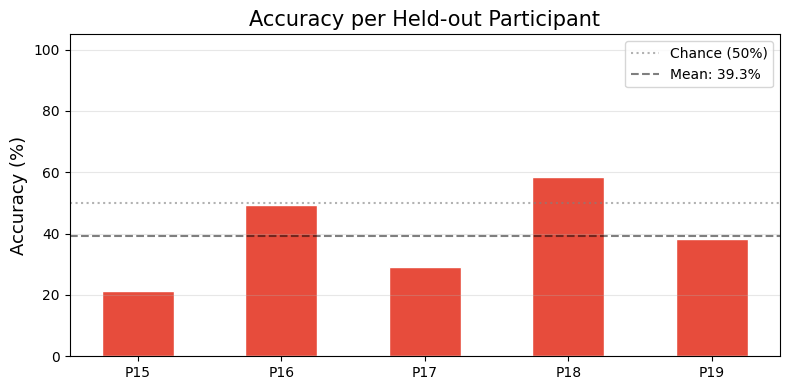

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

pids = [r["participant"] for r in loso_results]
accs = [r["acc"] * 100 for r in loso_results]

colors = ["#2ecc71" if a >= 80 else "#e67e22" if a >= 60 else "#e74c3c"
          for a in accs]
ax.bar([f"P{p}" for p in pids], accs, color=colors, edgecolor="white", width=0.5)

ax.set_ylabel("Accuracy (%)",fontsize=13)
ax.set_ylim(0, 105)
ax.set_title("Accuracy per Held-out Participant",fontsize=15)
ax.axhline(y=10, color="grey", linestyle=":", alpha=0.6, label="Chance (10%)")
grand_mean = np.mean(accs)
ax.axhline(y=grand_mean, color="black", linestyle="--", alpha=0.5,
           label=f"Mean: {grand_mean:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 11. Per-exercise breakdown — pooled LOSO results table

### How the numbers are computed

We pool predictions across all 5 LOSO folds into a single prediction array, then compute sklearn's `classification_report` on the pool. Each row reports four numbers for that specific exercise:

- **Accuracy/Recall:** of all windows that *actually* belonged to this exercise, what fraction did the model label correctly? (In per-class classification, accuracy for one class is exactly its recall.)
- **Precision:** of all windows the model *predicted* as this exercise, what fraction were actually that exercise?
- **F1 Score:** harmonic mean of precision and recall — `F1 = 2 × (P × R) / (P + R)`.
- **Support:** number of test windows for this exercise across all folds (the denominator for accuracy/recall).

### Why F1 works for every row now (unlike the 2-class notebook)

In the 2-class notebook, F1 was blank for individual exercises because the model never predicted at the exercise level — it only predicted "curl" vs "bench". Here the model outputs one of 10 class labels directly, so every class has a well-defined precision ("of everything predicted as Preacher Curls, how much actually was Preacher Curls?") and a well-defined F1.

### Macro-averaging vs micro-averaging

The "Total" row uses the **macro average** — the unweighted mean across the 10 per-class F1s. This treats every exercise as equally important regardless of how many windows it contributed. An alternative would be the micro average (which weights by support), but since our class distribution is roughly similar across exercises, the two are close in practice and macro is easier to interpret.

### A note on P17 and Alternate Dumbbell Curls

P17 did not perform `(1,1)` Alternate Dumbbell Curls during data collection. In the pooled evaluation this means that class's support is ~20% smaller than the other classes (contributions from 4 folds instead of 5). `classification_report` handles this natively — the per-class metrics for that class still compute correctly, just with a smaller denominator.

In [ ]:
# ============================================================
# 10-class per-exercise metrics
# ============================================================
from sklearn.metrics import classification_report

y_true_all = np.concatenate([r["y_true"] for r in loso_results])
y_pred_all = np.concatenate([r["y_pred"] for r in loso_results])

# Generate a dictionary report containing per-class Precision, Recall, and F1
report_dict = classification_report(
    y_true_all, y_pred_all,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

rows = []
for i, name in enumerate(class_names):
    # Note: P17 missing Alternate DB Curls (Class 0) is natively handled by the pooled metrics,
    # as the denominator for support will simply reflect the 4 folds that contained it.
    metrics = report_dict[name]
    rows.append({
        "Exercise Class": name,
        "Accuracy/Recall (%)": metrics["recall"] * 100,
        "Precision (%)": metrics["precision"] * 100,
        "F1 Score (%)": metrics["f1-score"] * 100,
        "Support (Windows)": metrics["support"]
    })

# Total row (Macro Average)
macro_metrics = report_dict["macro avg"]
rows.append({
    "Exercise Class": "Total (Macro Avg)",
    "Accuracy/Recall (%)": macro_metrics["recall"] * 100,
    "Precision (%)": macro_metrics["precision"] * 100,
    "F1 Score (%)": macro_metrics["f1-score"] * 100,
    "Support (Windows)": macro_metrics["support"]
})

writeup_df = pd.DataFrame(rows)
writeup_df["Accuracy/Recall (%)"] = writeup_df["Accuracy/Recall (%)"].round(2)
writeup_df["Precision (%)"] = writeup_df["Precision (%)"].round(2)
writeup_df["F1 Score (%)"] = writeup_df["F1 Score (%)"].round(2)

print("LOSO Pooled Per-Exercise Results (CNN-ResBiGRU, 10-class, OurData)")
print("=" * 75)
display(writeup_df)

LOSO Pooled Per-Exercise Results (CNN-ResBiGRU, 10-class, OurData)


,Exercise Class,Accuracy/Recall (%),Precision (%),F1 Score (%),Support (Windows)
0,Alternate DB Curl,68.92,40.52,51.03,251.0
1,Preacher Curl,31.44,47.43,37.81,264.0
2,BB Curl,40.61,60.92,48.74,261.0
3,Reverse BB Curl,80.37,79.49,79.93,270.0
4,Flat BB Press,14.22,29.29,19.14,204.0
5,Incline BB Press,20.65,25.63,22.87,247.0
6,Decline BB Press,30.00,14.58,19.63,210.0
7,Flat DB Press,20.68,31.07,24.83,266.0
8,Incline DB Press,21.01,38.85,27.27,257.0
9,Decline DB Press,41.06,27.14,32.68,263.0


---
## 12. Confusion matrices per held-out participant

One 10×10 confusion matrix per LOSO fold, with the 10 exercises on both axes. This is the richest single view of where the model goes wrong — you can see at a glance whether errors cluster within a family (e.g. confusing Flat BB Press with Incline BB Press) or cross families (e.g. misclassifying a curl as a bench press).

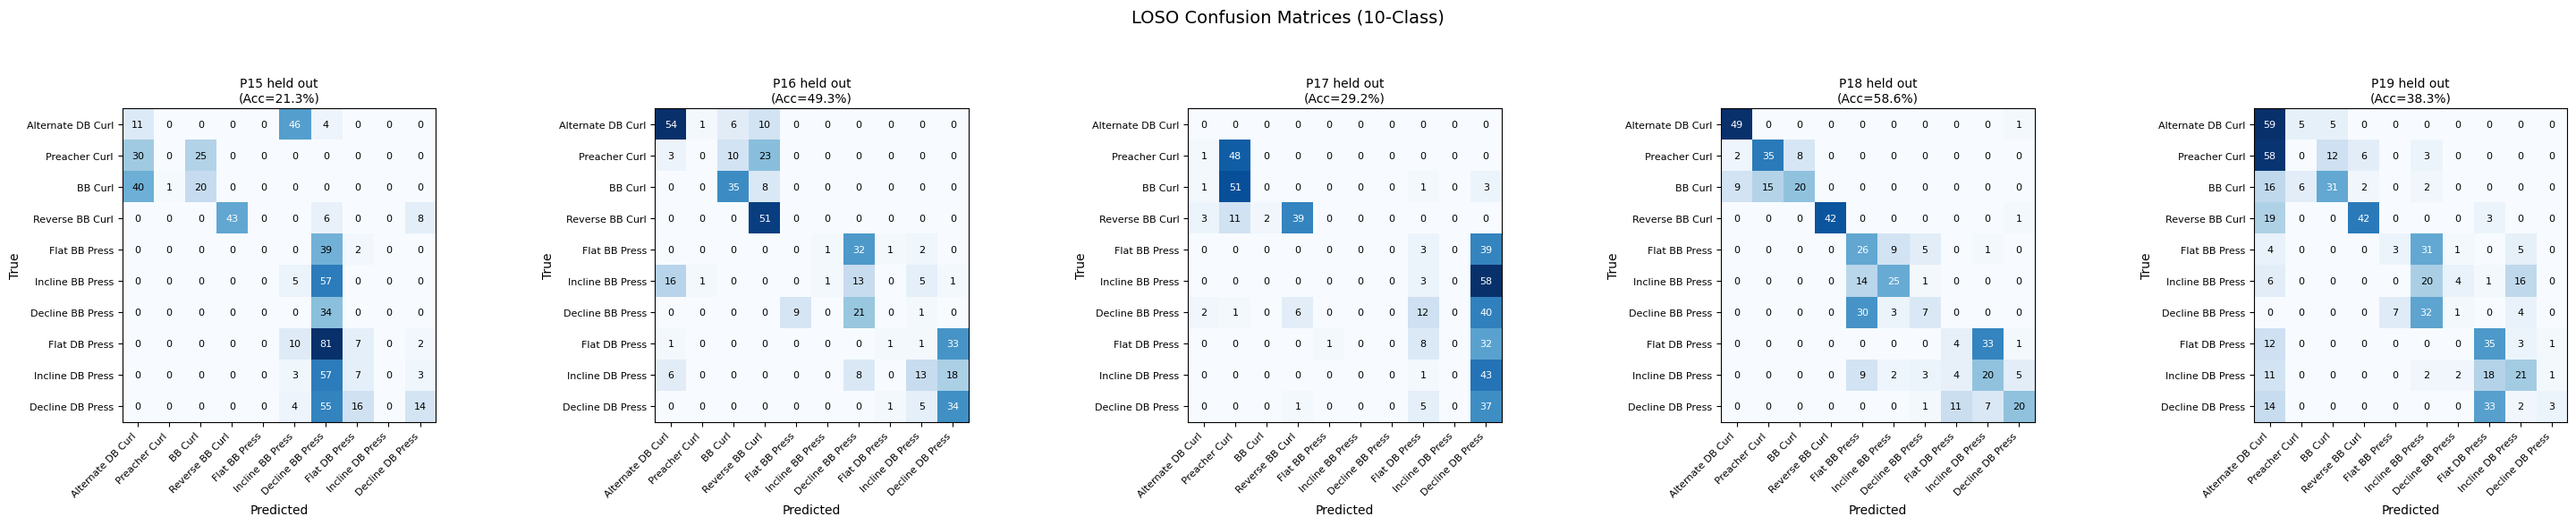

In [ ]:
n_folds = len(loso_results)
fig, axes = plt.subplots(1, n_folds, figsize=(6.0 * n_folds, 5.5), squeeze=False)
axes = axes[0]

for ax, r in zip(axes, loso_results):
    cm = r["cm"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))

    # Rotate x-labels by 45 degrees and align right
    ax.set_xticklabels(class_names, fontsize=8, rotation=45, ha="right")
    ax.set_yticklabels(class_names, fontsize=8)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"P{r['participant']} held out\n(Acc={r['acc']*100:.1f}%)", fontsize=10)

    # Adjust text size inside the matrix cells
    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=8)

plt.suptitle("LOSO Confusion Matrices (10-Class)", fontsize=14, y=1.05)
# Add tight_layout with padding to accommodate rotated labels
plt.tight_layout(pad=1.5)
plt.show()

---
## 13. Training curves

One subplot per fold showing how training and validation loss evolved across epochs. The curves will usually show training loss steadily decreasing while validation loss (on the held-out participant) dips and then flattens — the point where it flattens is roughly where early stopping kicks in.

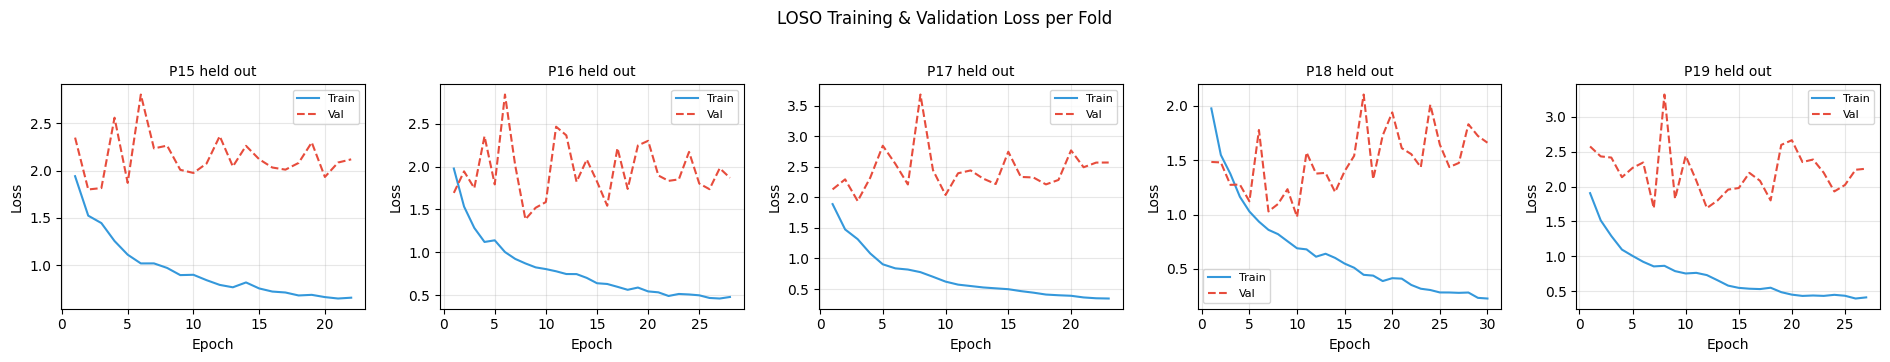

In [ ]:
fig, axes = plt.subplots(1, len(loso_results), figsize=(3.8 * len(loso_results), 3.5),
                        squeeze=False)
axes = axes[0]

for ax, r in zip(axes, loso_results):
    ep = range(1, len(r["history"]["train_loss"]) + 1)
    ax.plot(ep, r["history"]["train_loss"], label="Train", color="#3498db", linewidth=1.5)
    ax.plot(ep, r["history"]["val_loss"],   label="Val",   color="#e74c3c", linewidth=1.5,
            linestyle="--")
    ax.set_title(f"P{r['participant']} held out", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("LOSO Training & Validation Loss per Fold", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()